In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


import mysql.connector
db=mysql.connector.connect

# 1. Connect to your MySQL Workbench Database
db = mysql.connector.connect(
    host="localhost",
    user="root",           # Your MySQL username
    password="Rohan@123", # Your MySQL password
    database="supply_chain" # The name of your database
)

print("Connected successfully ✅")

# create cursor
cursor = db.cursor()

# run query
cursor.execute("SHOW DATABASES")

# print output
for i in cursor:
    print(i)


Connected successfully ✅
('db',)
('home_practise',)
('information_schema',)
('learn_join',)
('mydatabase',)
('mysql',)
('performance_schema',)
('practice',)
('salesdb',)
('sql_practice',)
('supply_chain',)
('sys',)


In [3]:
# SQL query
query = """
select distinct p.ProductName,s.ContactName from supplier s 
join product p on s.Id=p.SupplierId
join orderitem oi on p.id=oi.productid
where oi.UnitPrice>100;
"""
df = pd.read_sql(query, db)

print(df)

               ProductName     ContactName
0  Thüringer Rostbratwurst     Martin Bein
1            Côte de Blaye  Guylène Nodier


C:\Users\Rohan Srivastav\AppData\Local\Temp\ipykernel_9624\3335220222.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, db)


   total_order  Year_in
0          408     2013
1          270     2014
2          152     2012


C:\Users\Rohan Srivastav\AppData\Local\Temp\ipykernel_9624\3545705847.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query1, db)


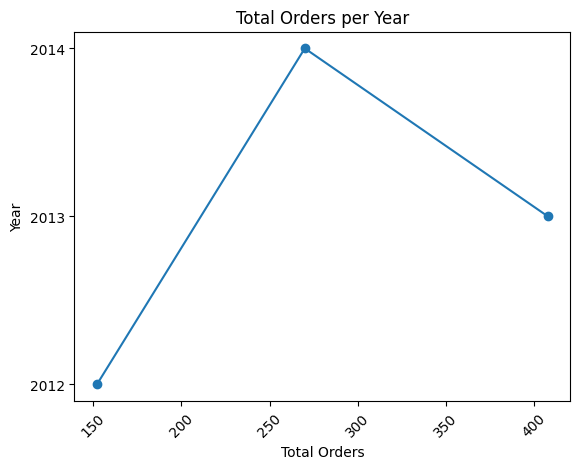

In [22]:
### 12. Display the total number of orders delivered every year

query1="""select count(id) as total_order,year(orderdate) as Year_in from orders
group by year(orderdate)
order by total_order desc;"""

# load data
df = pd.read_sql(query1, db)
# ensure Year_in is integer type, not float
df['Year_in'] = df['Year_in'].astype(int)
print(df)

plt.figure()
plt.plot(df['total_order'], df['Year_in'], marker='o')
plt.xticks(rotation=45)

plt.title("Total Orders per Year")
plt.ylabel("Year")
plt.yticks(df['Year_in'])
plt.xlabel("Total Orders")

plt.show()

C:\Users\Rohan Srivastav\AppData\Local\Temp\ipykernel_9624\2194086923.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql(query,db)


Text(0.5, 0, 'country')

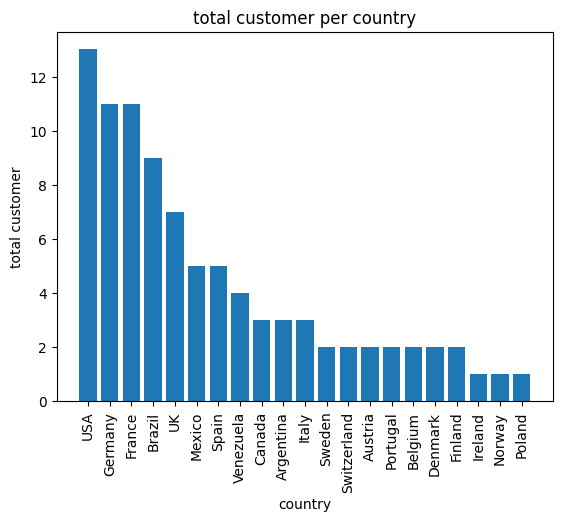

In [ ]:
query="""select country , count(id) as total_customer from  customer
group by country 
order by total_customer desc ;"""

df=pd.read_sql(query,db)
df

plt.figure()
plt.xticks(rotation=90)
plt.bar(df["country"],df["total_customer"])
plt.title("total customer per country")
plt.ylabel("total customer")
plt.xlabel("country")

C:\Users\Rohan Srivastav\AppData\Local\Temp\ipykernel_9624\1947079792.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, db)


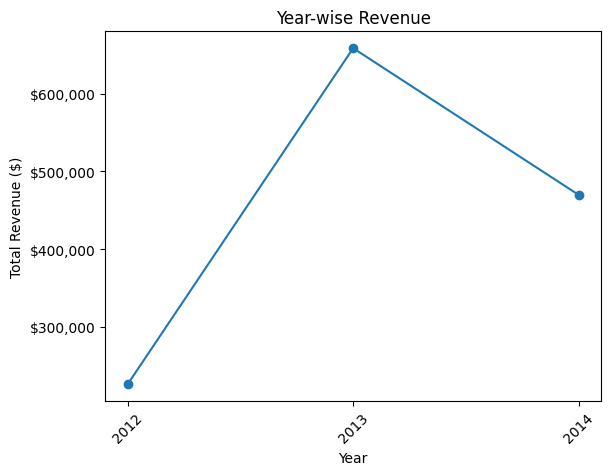

In [14]:
#1. 💰 Year-wise Revenue
query="""SELECT YEAR(orderdate) AS year, 
       SUM(totalamount) AS total_revenue 
FROM orders 
GROUP BY YEAR(orderdate)
ORDER BY year;"""

df = pd.read_sql(query, db)
# ensure year is integer type for plotting and display
df['year'] = df['year'].astype(int)
plt.figure()
plt.plot(df['year'], df['total_revenue'], marker='o')
plt.title("Year-wise Revenue") 
# --- THE FIX ---
# This tells Matplotlib to ONLY use the years present in your DataFrame for the X-axis ticks
plt.xticks(df['year'])
plt.xticks(rotation=45)
plt.xlabel("Year")
plt.ylabel("Total Revenue ($)")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.show()

C:\Users\Rohan Srivastav\AppData\Local\Temp\ipykernel_9624\2820055642.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql(query,db)


Text(0, 0.5, 'product name')

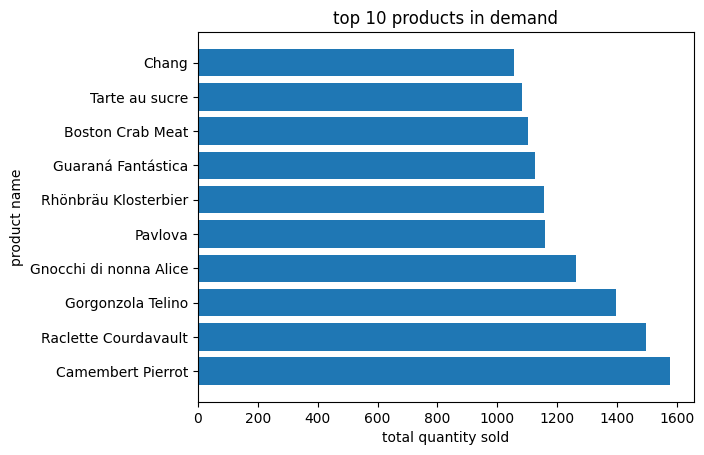

In [37]:
#2.  Product Demand (Top Products) that are in demand based on the quantity sold.
query= """SELECT p.productname, 
       SUM(oi.quantity) AS total_quantity
FROM orderitem oi 
JOIN product p ON p.id = oi.productid
GROUP BY p.productname 
ORDER BY total_quantity DESC
LIMIT 10;"""
df=pd.read_sql(query,db)
df
plt.Figure(figsize=(10, 6))
plt.barh(df["productname"],df["total_quantity"])
plt.title("top 10 products in demand")
plt.xlabel("total quantity sold")
plt.ylabel("product name")

C:\Users\Rohan Srivastav\AppData\Local\Temp\ipykernel_9624\3458448524.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql(query,db)


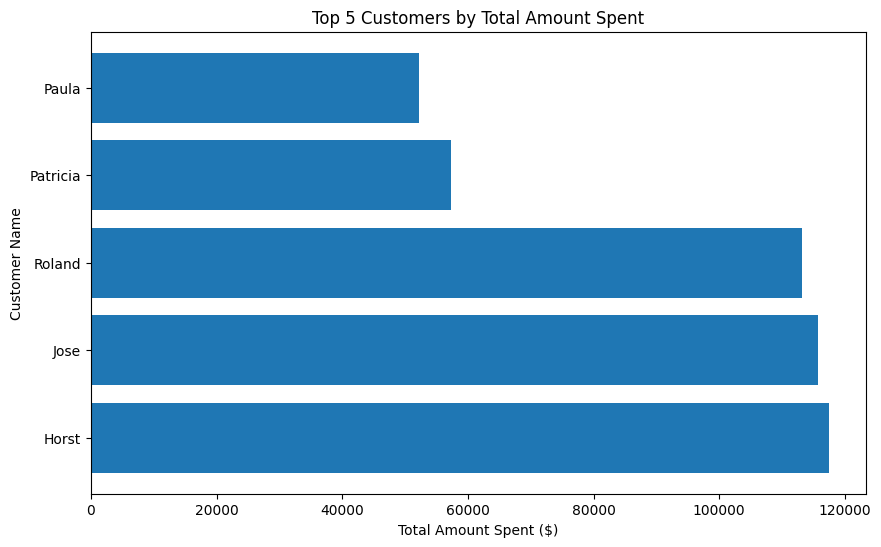

In [46]:
#3. 👤 Top Customers

#3 Section B → Q5 ### 5. Display the total amount ordered by each customer from high to low
query= """SELECT c.firstname, 
       SUM(o.totalamount) AS total_spent 
FROM customer c
JOIN orders o ON o.customerid = c.id
GROUP BY c.id 
ORDER BY total_spent DESC
LIMIT 5;"""

df=pd.read_sql(query,db)
df
plt.figure(figsize=(10, 6))
plt.barh(df["firstname"],df["total_spent"])
plt.title("Top 5 Customers by Total Amount Spent")
plt.xlabel("Total Amount Spent ($)")        
plt.ylabel("Customer Name")
plt.show()


C:\Users\Rohan Srivastav\AppData\Local\Temp\ipykernel_9624\3609545063.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql(qerty,db)


([0, 1, 2, 3, 4],
 [Text(0, 0, 'Guylène Nodier'),
  Text(1, 0, 'Martin Bein'),
  Text(2, 0, 'Eliane Noz'),
  Text(3, 0, 'Ian Devling'),
  Text(4, 0, 'Wendy Mackenzie')])

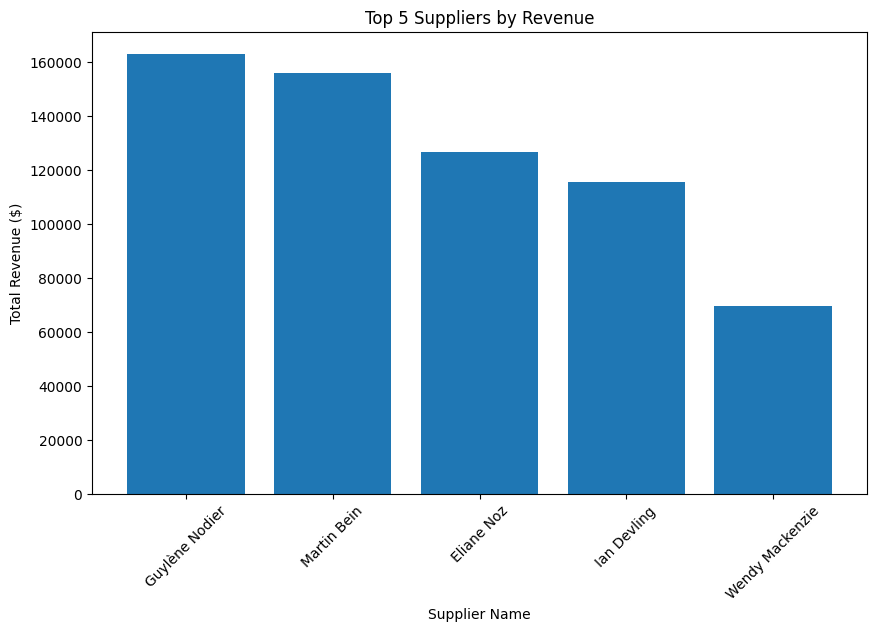

In [48]:
#4.Top Suppliers by Revenue
qerty= """SELECT s.contactname, 
       SUM(oi.quantity * oi.unitprice) AS totalrevenue
FROM supplier s
JOIN product p ON s.id = p.supplierid
JOIN orderitem oi ON oi.productid = p.id
GROUP BY s.id
ORDER BY totalrevenue DESC
LIMIT 5;"""
df=pd.read_sql(qerty,db)
df
plt.figure(figsize=(10, 6)) 
plt.bar(df["contactname"], df["totalrevenue"])
plt.title("Top 5 Suppliers by Revenue")
plt.xlabel("Supplier Name")
plt.ylabel("Total Revenue ($)")
plt.xticks(rotation=45)

C:\Users\Rohan Srivastav\AppData\Local\Temp\ipykernel_9624\1575424958.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql(query,db)


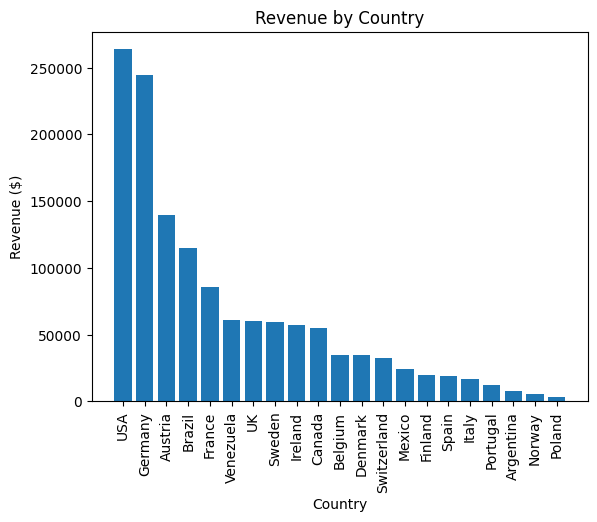

In [54]:
#🌍 Revenue by Country
query="""SELECT c.country, 
       SUM(o.totalamount) AS revenue
FROM customer c
JOIN orders o ON o.customerid = c.id
GROUP BY c.country
ORDER BY revenue DESC;"""

df=pd.read_sql(query,db)    
df
plt.bar(df["country"], df["revenue"])
plt.title("Revenue by Country")     
plt.xlabel("Country")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=90)
plt.show()